<a href="https://colab.research.google.com/github/lamaljalal/ImageProcessing/blob/main/Lab3_Image_Manipulations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display


Saving cameraman.png to cameraman.png


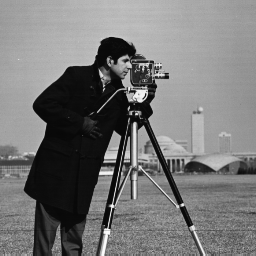

In [2]:
uploaded = files.upload()
image_name = next(iter(uploaded))
img = Image.open(image_name).convert('RGB')
display(img)


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
width, height = img.size
cx, cy = 2, 2
new_width, new_height = int(width * cx), int(height * cy)
print('Original size:', img.size)
print('New size:', (new_width, new_height))


Original size: (256, 256)
New size: (512, 512)


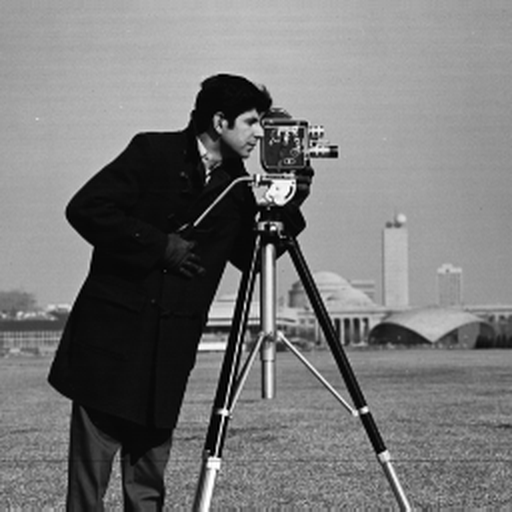

In [4]:
scaled_img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)
display(scaled_img)


In [5]:
scaled_img.save('task1_1_scaled.jpg')
print('Original size:', img.size)
print('Scaled size:', scaled_img.size)
files.download('task1_1_scaled.jpg')


Original size: (256, 256)
Scaled size: (512, 512)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

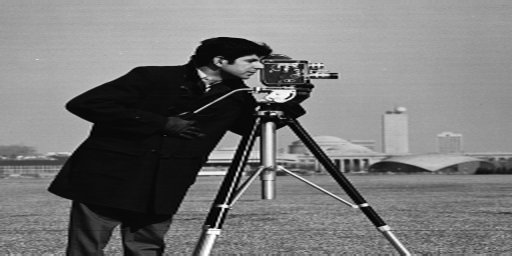

In [6]:
cx, cy = 2, 1
non_uniform_size = (int(width * cx), int(height * cy))
non_uniform_img = img.resize(non_uniform_size, Image.Resampling.LANCZOS)
display(non_uniform_img)


In [7]:
non_uniform_img.save('task1_1_nonuniform_scaled.jpg')
print('Original size:', img.size)
print('Non-uniform scaled size:', non_uniform_img.size)
files.download('task1_1_nonuniform_scaled.jpg')


Original size: (256, 256)
Non-uniform scaled size: (512, 256)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

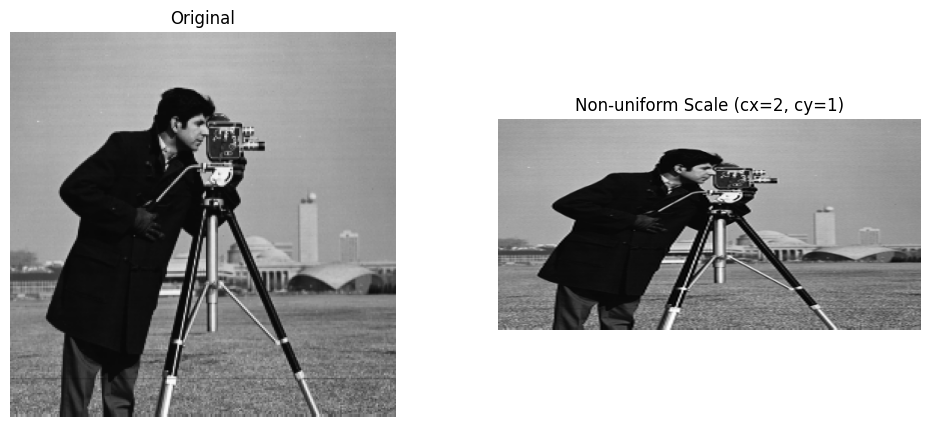

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(non_uniform_img)
plt.title('Non-uniform Scale (cx=2, cy=1)')
plt.axis('off')
plt.show()


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (256, 256)
Rotated size: (350, 350)


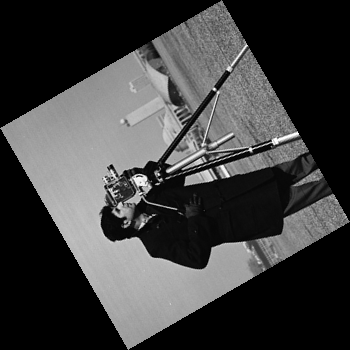

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
rotated_img = img.rotate(120, resample=Image.Resampling.BICUBIC, expand=True)
rotated_img.save('task1_2_rotated.jpg')
print('Original size:', img.size)
print('Rotated size:', rotated_img.size)
display(rotated_img)
files.download('task1_2_rotated.jpg')


### 3. Shear

In [10]:
width, height = img.size
print('Width:', width)
print('Height:', height)


Width: 256
Height: 256


In [11]:
shx = 0.5
shy = 0.0
new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)


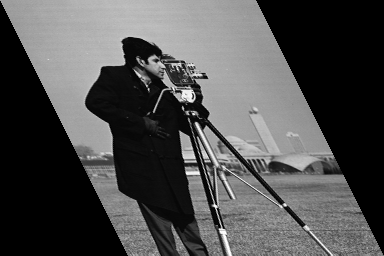

In [12]:
tx = 0 if shx >= 0 else abs(shx) * height
ty = 0 if shy >= 0 else abs(shy) * width
sheared_img = img.transform((new_width, new_height), Image.Transform.AFFINE, (1, -shx, tx, -shy, 1, ty), resample=Image.Resampling.BICUBIC)
display(sheared_img)


In [13]:
sheared_img.save('task1_3_sheared.jpg')
print('Original size:', img.size)
print('Sheared size:', sheared_img.size)
files.download('task1_3_sheared.jpg')


Original size: (256, 256)
Sheared size: (384, 256)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

factors = [0.1, 0.3, 0.5, 0.8]
plt.figure(figsize=(16, 4))
for i, factor in enumerate(factors, 1):
    canvas_width = int(width + factor * height)
    result = img.transform((canvas_width, height), Image.Transform.AFFINE, (1, -factor, 0, 0, 1, 0), resample=Image.Resampling.BICUBIC)
    result.save(f'task1_3_shear_x_{factor}.jpg')
    plt.subplot(1, 4, i)
    plt.imshow(result)
    plt.title(f'X Shear = {factor}')
    plt.axis('off')
plt.tight_layout()
plt.show()

shy = 0.5
y_canvas_height = int(height + shy * width)
y_shear = img.transform((width, y_canvas_height), Image.Transform.AFFINE, (1, 0, 0, -shy, 1, 0), resample=Image.Resampling.BICUBIC)
y_shear.save('task1_3_shear_y_0.5.jpg')
display(y_shear)

shx, shy = 0.3, 0.3
xy_width = int(width + shx * height)
xy_height = int(height + shy * width)
xy_shear = img.transform((xy_width, xy_height), Image.Transform.AFFINE, (1, -shx, 0, -shy, 1, 0), resample=Image.Resampling.BICUBIC)
xy_shear.save('task1_3_shear_xy_0.3.jpg')
display(xy_shear)


# Intensity Transformations
Negative · Log · Power Law (Gamma)

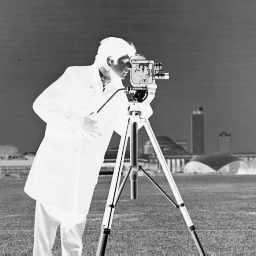

In [14]:
img_array = np.array(img)
negative_array = 255 - img_array
negative_numpy = Image.fromarray(negative_array.astype(np.uint8))
negative_numpy.save('task2_1_negative_numpy.jpg')
display(negative_numpy)


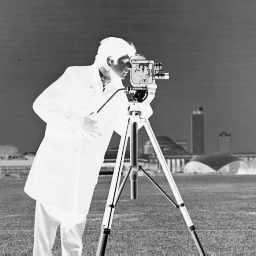

In [15]:
negative_pil = ImageOps.invert(img)
negative_pil.save('task2_1_negative_pil.jpg')
display(negative_pil)


c = 45.98590442833571


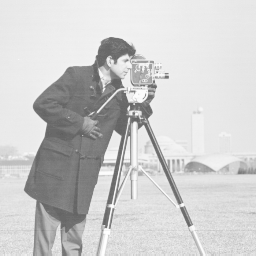

In [16]:
c = 255 / np.log1p(255)
log_array = c * np.log1p(img_array.astype(np.float32))
log_array = np.clip(log_array, 0, 255).astype(np.uint8)
log_img = Image.fromarray(log_array)
log_img.save('task2_2_log.jpg')
print('c =', c)
display(log_img)


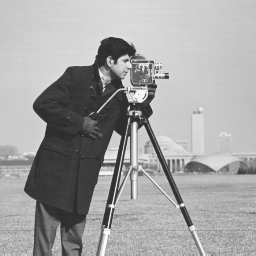

In [17]:
gamma = 0.5
normalized = img_array.astype(np.float32) / 255.0
gamma_array = 255 * np.power(normalized, gamma)
gamma_array = np.clip(gamma_array, 0, 255).astype(np.uint8)
gamma_img = Image.fromarray(gamma_array)
gamma_img.save('task2_3_gamma.jpg')
display(gamma_img)


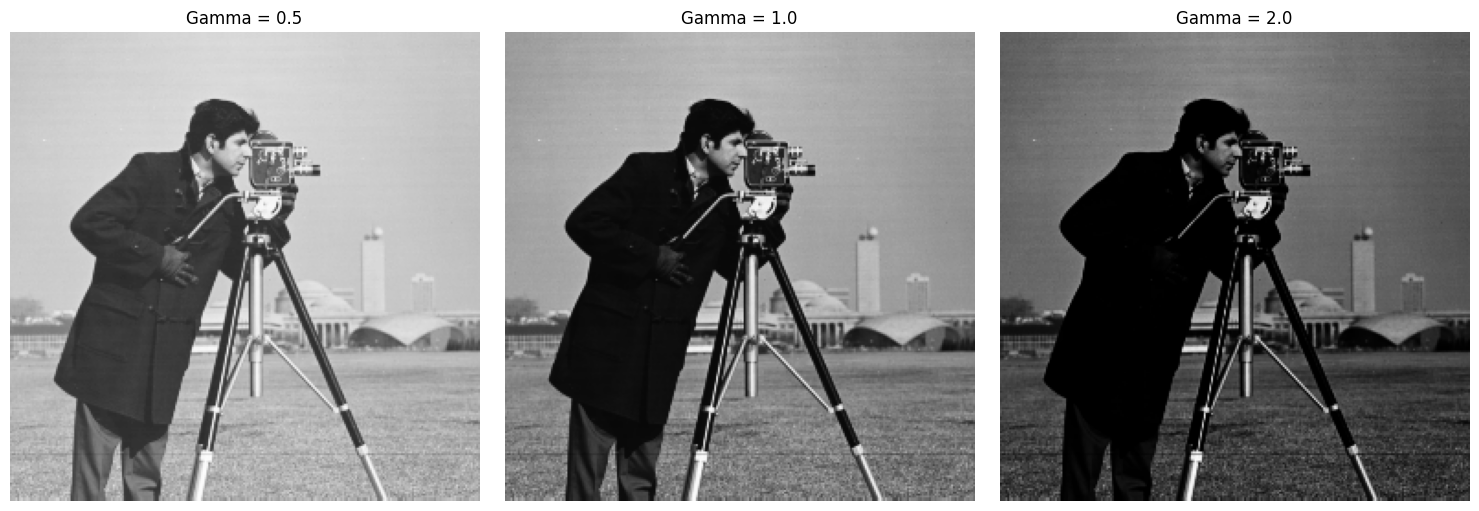

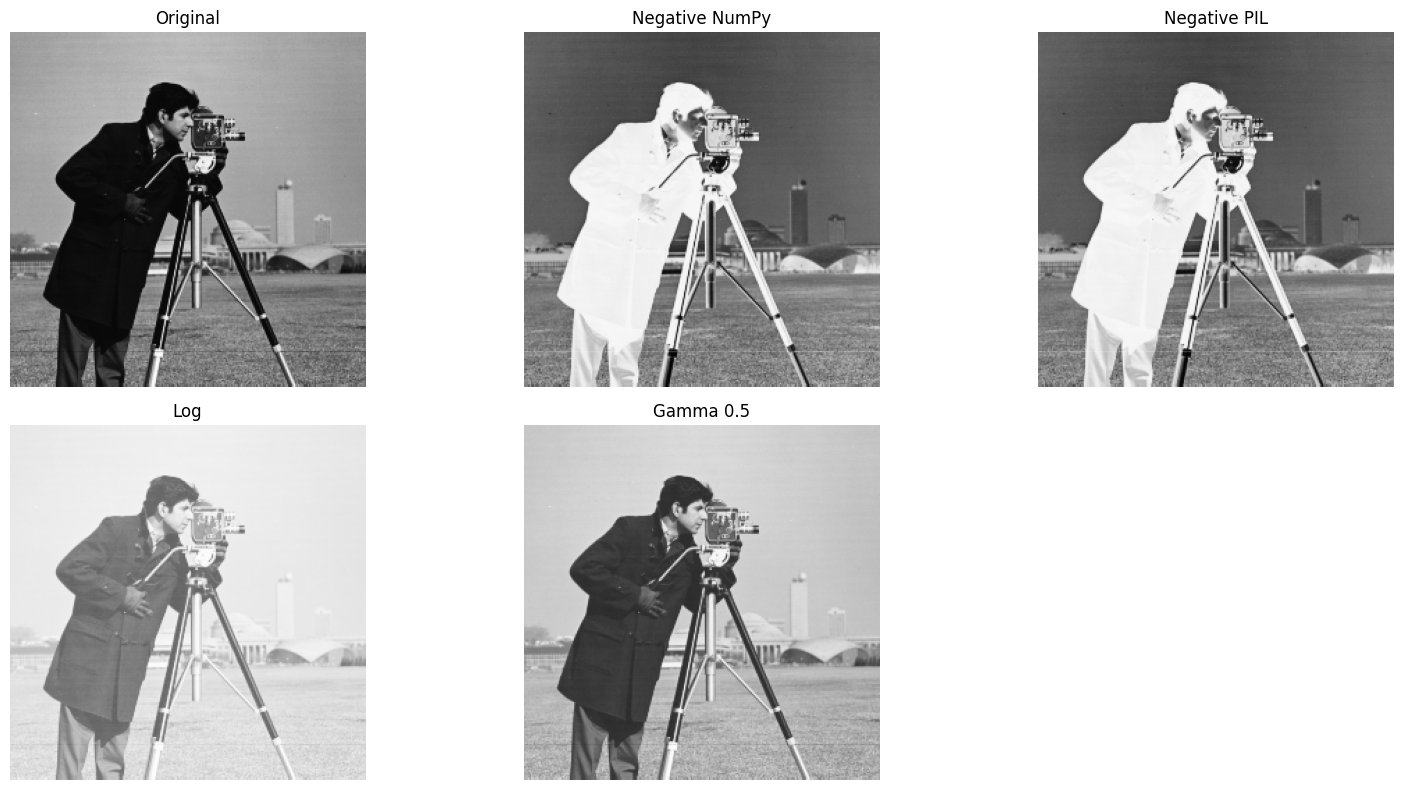

In [18]:
gammas = [0.5, 1.0, 2.0]
plt.figure(figsize=(15, 5))
for i, g in enumerate(gammas, 1):
    result_array = 255 * np.power(normalized, g)
    result_array = np.clip(result_array, 0, 255).astype(np.uint8)
    result = Image.fromarray(result_array)
    result.save(f'task2_3_gamma_{g}.jpg')
    plt.subplot(1, 3, i)
    plt.imshow(result)
    plt.title(f'Gamma = {g}')
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 8))
images = [img, negative_numpy, negative_pil, log_img, gamma_img]
titles = ['Original', 'Negative NumPy', 'Negative PIL', 'Log', 'Gamma 0.5']
for i, (image, title) in enumerate(zip(images, titles), 1):
    plt.subplot(2, 3, i)
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()
